In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision.models import efficientnet_b0
import time
import os

In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!find '/content/drive/MyDrive' -name "fer2013.csv"

/content/drive/MyDrive/Colab Notebooks/Reconhecimento de Emoções - TCC/fer2013.csv


## 1. Carregamento e exploração dos dados

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Reconhecimento de Emoções - TCC/fer2013.csv')

print("Dataset original:")
print(f"Shape: {df.shape}")
print(f"Distribuição das emoções:\n{df['emotion'].value_counts()}")

Dataset original:
Shape: (35887, 3)
Distribuição das emoções:
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


# 2. Filtro e remapeamento

In [5]:
# Filtrar apenas as 4 emoções desejadas
emotions_to_keep = [0, 3, 4, 6]  # Angry, Happy, Sad, Neutral
emotion_names = {0: 'Angry', 3: 'Happy', 4: 'Sad', 6: 'Neutral'}

df_filtered = df[df['emotion'].isin(emotions_to_keep)].copy()

# Remapear labels para 0, 1, 2, 3
emotion_mapping = {0: 0, 3: 1, 4: 2, 6: 3}  # Angry->0, Happy->1, Sad->2, Neutral->3
df_filtered['emotion'] = df_filtered['emotion'].map(emotion_mapping)
emotion_labels = ['Angry', 'Happy', 'Sad', 'Neutral']

print(f"\nApós remapeamento:")
for i, label in enumerate(emotion_labels):
    count = (df_filtered['emotion'] == i).sum()
    print(f"{i} - {label}: {count}")


Após remapeamento:
0 - Angry: 4953
1 - Happy: 8989
2 - Sad: 6077
3 - Neutral: 6198


## 3. Conversão de pixels em imagens

In [6]:
def pixels_to_image(pixel_string, size=(48, 48)):
    """Converte string de pixels em array numpy"""
    pixels = np.array(pixel_string.split(), dtype=np.float32)
    return pixels.reshape(size)

## 4. Visualizar amostras


Visualizando amostras...


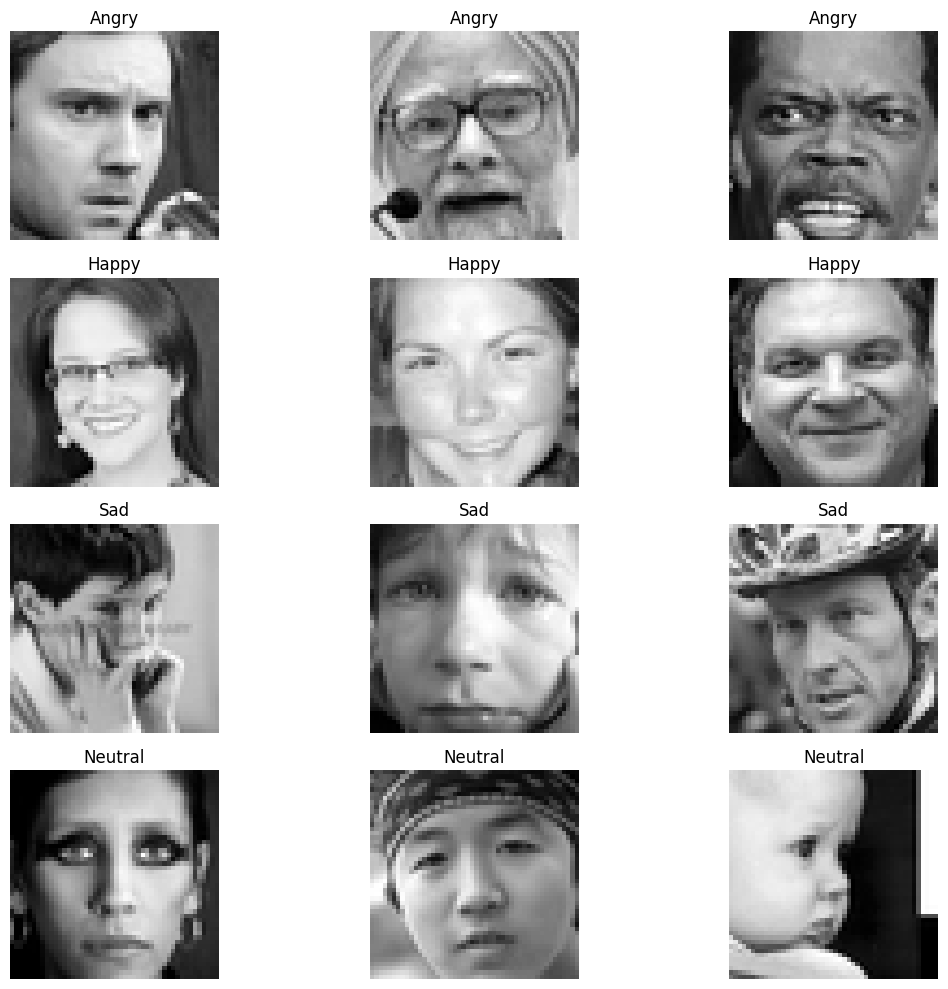

In [7]:
def visualize_samples(df, n_samples=3):
    """Visualiza algumas amostras de cada emoção"""
    fig, axes = plt.subplots(4, n_samples, figsize=(12, 10))

    for emotion in range(4):
        samples = df[df['emotion'] == emotion].head(n_samples)

        for i, (_, row) in enumerate(samples.iterrows()):
            img = pixels_to_image(row['pixels'])
            axes[emotion, i].imshow(img, cmap='gray')
            axes[emotion, i].set_title(f'{emotion_labels[emotion]}')
            axes[emotion, i].axis('off')

    plt.tight_layout()
    plt.show()

print("\nVisualizando amostras...")
visualize_samples(df_filtered)

## 5. Data augmentation para balanceamento das classes

In [8]:
def augment_image(img, rotation_range=10, width_shift_range=0.1,
                  height_shift_range=0.1, brightness_range=0.2, horizontal_flip=True):
    """Aplica data augmentation em uma imagem"""
    h, w = img.shape

    # Rotação
    if rotation_range > 0:
        angle = np.random.uniform(-rotation_range, rotation_range)
        center = (w//2, h//2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h))

    # Translação
    if width_shift_range > 0 or height_shift_range > 0:
        tx = np.random.uniform(-width_shift_range, width_shift_range) * w
        ty = np.random.uniform(-height_shift_range, height_shift_range) * h
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        img = cv2.warpAffine(img, M, (w, h))

    # Flip horizontal
    if horizontal_flip and np.random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Ajuste de brilho
    if brightness_range > 0:
        brightness = np.random.uniform(1-brightness_range, 1+brightness_range)
        img = np.clip(img * brightness, 0, 255)

    return img.astype(np.float32)

In [9]:
def balance_dataset(df, target_count=7000):
    """Balanceia dataset usando data augmentation"""
    balanced_data = []

    for emotion in range(4):
        emotion_data = df[df['emotion'] == emotion]
        current_count = len(emotion_data)

        print(f"\n{emotion_labels[emotion]} - Amostras originais: {current_count}")

        # Adicionar todas as amostras originais
        for _, row in emotion_data.iterrows():
            img = pixels_to_image(row['pixels'])
            balanced_data.append({
                'emotion': emotion,
                'pixels': row['pixels'],
                'usage': row['Usage'],
                'augmented': False
            })

        # Se precisar de mais amostras, fazer augmentation
        if current_count < target_count:
            needed = target_count - current_count
            print(f"Gerando {needed} amostras com data augmentation...")

            # Usar apenas dados de treino para augmentation
            train_samples = emotion_data[emotion_data['Usage'] == 'Training']

            for i in range(needed):
                # Escolher amostra aleatória
                sample = train_samples.sample(1).iloc[0]
                img = pixels_to_image(sample['pixels'])

                # Aplicar augmentation
                aug_img = augment_image(img)

                # Converter de volta para string de pixels
                aug_pixels = ' '.join(map(str, aug_img.astype(int).flatten()))

                balanced_data.append({
                    'emotion': emotion,
                    'pixels': aug_pixels,
                    'usage': 'Training',  # Augmented sempre vai para treino
                    'augmented': True
                })

        final_count = current_count + (needed if current_count < target_count else 0)
        print(f"Total final: {final_count}")

    return pd.DataFrame(balanced_data)

In [10]:
# Aplicar balanceamento
print("\n" + "="*50)
print("APLICANDO DATA AUGMENTATION...")
print("="*50)

df_balanced = balance_dataset(df_filtered)

print(f"\nDataset balanceado:")
for i, label in enumerate(emotion_labels):
    count = (df_balanced['emotion'] == i).sum()
    original = (df_balanced['emotion'] == i) & (~df_balanced['augmented'])
    augmented = (df_balanced['emotion'] == i) & (df_balanced['augmented'])
    print(f"{label}: {count} total ({original.sum()} originais + {augmented.sum()} augmentadas)")


APLICANDO DATA AUGMENTATION...

Angry - Amostras originais: 4953
Gerando 2047 amostras com data augmentation...
Total final: 7000

Happy - Amostras originais: 8989
Total final: 8989

Sad - Amostras originais: 6077
Gerando 923 amostras com data augmentation...
Total final: 7000

Neutral - Amostras originais: 6198
Gerando 802 amostras com data augmentation...
Total final: 7000

Dataset balanceado:
Angry: 7000 total (4953 originais + 2047 augmentadas)
Happy: 8989 total (8989 originais + 0 augmentadas)
Sad: 7000 total (6077 originais + 923 augmentadas)
Neutral: 7000 total (6198 originais + 802 augmentadas)


## 6. Divisão treino/validação/teste

In [11]:
# Separar por Usage original
train_data = df_balanced[df_balanced['usage'] == 'Training']
test_data = df_balanced[df_balanced['usage'] == 'PublicTest']

# Dividir treino em treino/validação (80/20)
train_df, val_df = train_test_split(train_data, test_size=0.2,
                                   stratify=train_data['emotion'], random_state=42)

print(f"\nDivisão final dos dados:")
print(f"Treino: {len(train_df)} amostras")
print(f"Validação: {len(val_df)} amostras")
print(f"Teste: {len(test_data)} amostras")

# Verificar distribuição por classe
print(f"\nDistribuição por classe:")
for i, label in enumerate(emotion_labels):
    train_count = (train_df['emotion'] == i).sum()
    val_count = (val_df['emotion'] == i).sum()
    test_count = (test_data['emotion'] == i).sum()
    print(f"{label}: Train={train_count}, Val={val_count}, Test={test_count}")

print("\n✅ Pré-processamento concluído!")
print("Próximo passo: Criar Dataset class e DataLoaders do PyTorch")


Divisão final dos dados:
Treino: 19821 amostras
Validação: 4956 amostras
Teste: 2622 amostras

Distribuição por classe:
Angry: Train=4833, Val=1209, Test=467
Happy: Train=5772, Val=1443, Test=895
Sad: Train=4602, Val=1151, Test=653
Neutral: Train=4614, Val=1153, Test=607

✅ Pré-processamento concluído!
Próximo passo: Criar Dataset class e DataLoaders do PyTorch


## 7. Dataset class

In [12]:
class EmotionDataset(Dataset):
    """Dataset customizado para reconhecimento de emoções"""

    def __init__(self, dataframe, transform=None, target_size=(224, 224)):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Converter pixels para imagem
        pixel_string = self.data.iloc[idx]['pixels']
        pixels = np.array(pixel_string.split(), dtype=np.float32)
        image = pixels.reshape(48, 48)

        # Redimensionar para 224x224 (padrão ImageNet/EfficientNet)
        image = cv2.resize(image, self.target_size)

        # Converter para 3 canais (RGB) duplicando o canal gray
        image = np.stack([image, image, image], axis=2)

        # Normalizar para [0, 1]
        image = image / 255.0

        # Aplicar transformações se fornecidas
        if self.transform:
            # Converter para PIL Image para usar transforms do torchvision
            from PIL import Image
            image_pil = Image.fromarray((image * 255).astype(np.uint8))
            image = self.transform(image_pil)
        else:
            # Converter para tensor manualmente
            image = torch.FloatTensor(image).permute(2, 0, 1)  # HWC -> CHW

        # Label
        label = torch.LongTensor([self.data.iloc[idx]['emotion']])[0]

        return image, label

## 8. Transformações para treino

In [13]:
# Transformações para treino (com augmentation)
train_transforms = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Padrão ImageNet
                        std=[0.229, 0.224, 0.225])
])

In [14]:
# Transformações para validação/teste (sem augmentation)
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [15]:
# Criar datasets
train_dataset = EmotionDataset(train_df, transform=train_transforms)
val_dataset = EmotionDataset(val_df, transform=val_transforms)
test_dataset = EmotionDataset(test_data, transform=val_transforms)

In [16]:
# Criar dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Dataloaders criados:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Dataloaders criados:
Train batches: 620
Val batches: 155
Test batches: 82


In [17]:
# Testar um batch
sample_batch = next(iter(train_loader))
print(f"\nShape do batch: {sample_batch[0].shape}")  # [batch_size, 3, 224, 224]
print(f"Labels shape: {sample_batch[1].shape}")      # [batch_size]


Shape do batch: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## 9. Modelo EFFICIENTNET-B0

In [18]:
class EmotionClassifier(nn.Module):
    """Modelo baseado em EfficientNet-B0 para classificação de emoções"""

    def __init__(self, num_classes=4, dropout=0.3):
        super(EmotionClassifier, self).__init__()

        # EfficientNet-B0 pré-treinado
        self.backbone = efficientnet_b0(pretrained=True)

        # Congelar algumas camadas iniciais para transfer learning
        for param in list(self.backbone.parameters())[:-20]:
            param.requires_grad = False

        # Substituir o classificador final
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout/2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [19]:
# Criar modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

model = EmotionClassifier(num_classes=4, dropout=0.3)
model = model.to(device)

Usando device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 105MB/s]


In [20]:
# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModelo criado:")
print(f"Total de parâmetros: {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")


Modelo criado:
Total de parâmetros: 4,172,032
Parâmetros treináveis: 1,294,260


## 10. Configuração de treino

In [21]:
# Loss function com pesos para classes desbalanceadas
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos das classes
y_train = train_df['emotion'].values
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"Pesos das classes: {class_weights}")

# Configurar otimizador e loss
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler para ajustar learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                     patience=3, factor=0.5)

Pesos das classes: tensor([1.0253, 0.8585, 1.0768, 1.0740], device='cuda:0')


## 11. Funções de treino e avaliação

In [22]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Treina por uma época"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)

        # Print progress
        if batch_idx % 100 == 0:
            print(f'Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy

In [23]:
def validate_epoch(model, val_loader, criterion, device):
    """Avalia o modelo"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)

            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = 100. * correct / total

    # Calcular F1-score
    from sklearn.metrics import f1_score, classification_report
    f1 = f1_score(all_targets, all_preds, average='weighted')

    return avg_loss, accuracy, f1, all_preds, all_targets

## 12. Loop de treinamento

In [24]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=10, device='cuda'):
    """Loop principal de treinamento"""

    best_val_acc = 0.0
    best_val_f1 = 0.0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    val_f1s = []

    print(f"Iniciando treinamento por {num_epochs} épocas...")
    print("="*60)

    for epoch in range(num_epochs):
        start_time = time.time()

        print(f"Época {epoch+1}/{num_epochs}")
        print("-" * 30)

        # Treino
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validação
        val_loss, val_acc, val_f1, _, _ = validate_epoch(model, val_loader, criterion, device)

        # Scheduler step
        scheduler.step(val_acc)

        # Salvar métricas
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        val_f1s.append(val_f1)

        # Salvar melhor modelo
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_emotion_model.pth')
            print("✅ Novo melhor modelo salvo!")

        epoch_time = time.time() - start_time

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}")
        print(f"Tempo da época: {epoch_time:.1f}s")
        print(f"Melhor Val Acc: {best_val_acc:.2f}%")
        print("="*60)

    print(f"Treinamento concluído!")
    print(f"Melhor acurácia de validação: {best_val_acc:.2f}%")
    print(f"Melhor F1-score de validação: {best_val_f1:.4f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'val_f1s': val_f1s,
        'best_val_acc': best_val_acc,
        'best_val_f1': best_val_f1
    }

print("\n✅ Modelo e funções de treino configurados!")


✅ Modelo e funções de treino configurados!


In [25]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=5)

Iniciando treinamento por 5 épocas...
Época 1/5
------------------------------
Batch 0/620, Loss: 1.4134
Batch 100/620, Loss: 1.2865
Batch 200/620, Loss: 1.4615
Batch 300/620, Loss: 1.1080
Batch 400/620, Loss: 1.0941
Batch 500/620, Loss: 1.1254
Batch 600/620, Loss: 1.2382
✅ Novo melhor modelo salvo!
Train Loss: 1.1832, Train Acc: 47.93%
Val Loss: 1.0216, Val Acc: 56.80%, Val F1: 0.5723
Tempo da época: 110.9s
Melhor Val Acc: 56.80%
Época 2/5
------------------------------
Batch 0/620, Loss: 1.0042
Batch 100/620, Loss: 0.9137
Batch 200/620, Loss: 0.9636
Batch 300/620, Loss: 1.0766
Batch 400/620, Loss: 1.0324
Batch 500/620, Loss: 0.8117
Batch 600/620, Loss: 1.1179
✅ Novo melhor modelo salvo!
Train Loss: 1.0043, Train Acc: 58.00%
Val Loss: 0.9470, Val Acc: 61.92%, Val F1: 0.6118
Tempo da época: 107.5s
Melhor Val Acc: 61.92%
Época 3/5
------------------------------
Batch 0/620, Loss: 1.0054
Batch 100/620, Loss: 0.8102
Batch 200/620, Loss: 0.9918
Batch 300/620, Loss: 1.0627
Batch 400/620, Lo

# Detecção de Emoções

In [ ]:
import cv2
import torch
import numpy as np
import mediapipe as mp
from PIL import Image
import torchvision.transforms as transforms

## 1. Configurações do Mediapipe

In [ ]:
class FaceDetector:
    """Detector de faces usando MediaPipe"""

    def __init__(self):
        self.mp_face_detection = mp.solutions.face_detection
        self.mp_drawing = mp.solutions.drawing_utils
        self.face_detection = self.mp_face_detection.FaceDetection(
            model_selection=0,  # 0 para faces próximas, 1 para faces distantes
            min_detection_confidence=0.5
        )

    def detect_faces(self, image):
        """Detecta faces na imagem e retorna coordenadas"""
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.face_detection.process(rgb_image)

        faces = []
        if results.detections:
            for detection in results.detections:
                bbox = detection.location_data.relative_bounding_box
                h, w, _ = image.shape

                # Converter coordenadas relativas para absolutas
                x = int(bbox.xmin * w)
                y = int(bbox.ymin * h)
                width = int(bbox.width * w)
                height = int(bbox.height * h)

                # Garantir que as coordenadas estão dentro da imagem
                x = max(0, x)
                y = max(0, y)
                width = min(w - x, width)
                height = min(h - y, height)

                faces.append((x, y, width, height))

        return faces

## 2. Classe de Predição

In [ ]:
class EmotionPredictor:
    """Preditor de emoções usando modelo treinado"""

    def __init__(self, model_path='best_emotion_model.pth'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.emotion_labels = ['Angry', 'Happy', 'Sad', 'Neutral']

        # Carregar modelo
        self.model = EmotionClassifier(num_classes=4)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model = self.model.to(self.device)
        self.model.eval()

        # Transformações (mesmo que foi usado no treino)
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        print(f"Modelo carregado no device: {self.device}")

    def preprocess_face(self, face_image):
        """Pré-processa imagem da face para predição"""
        # Converter para RGB se necessário
        if len(face_image.shape) == 3:
            face_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB)

        # Converter para PIL Image
        pil_image = Image.fromarray(face_image)

        # Converter para grayscale e duplicar canais (simular RGB)
        gray_image = pil_image.convert('L')
        rgb_image = Image.merge('RGB', (gray_image, gray_image, gray_image))

        # Aplicar transformações
        tensor = self.transform(rgb_image).unsqueeze(0)  # Adicionar batch dimension

        return tensor.to(self.device)

    def predict(self, face_image):
        """Prediz emoção da face"""
        with torch.no_grad():
            # Pré-processar
            tensor = self.preprocess_face(face_image)

            # Predição
            output = self.model(tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1)

            # Obter classe predita e confiança
            confidence, predicted = torch.max(probabilities, 1)

            emotion = self.emotion_labels[predicted.item()]
            conf_score = confidence.item()

            return emotion, conf_score, probabilities[0].cpu().numpy()

## Upload de imagem

In [ ]:
def test_with_uploaded_image():
    """Testa modelo com imagem enviada - FUNCIONA NO COLAB"""

    from google.colab import files
    from IPython.display import Image as IPImage, display
    import matplotlib.patches as patches

    print("📸 Faça upload de uma imagem com faces:")
    uploaded = files.upload()

    if not uploaded:
        print("❌ Nenhuma imagem enviada")
        return

    # Processar cada imagem enviada
    for filename in uploaded.keys():
        print(f"\n🔍 Processando: {filename}")

        # Carregar imagem
        image = cv2.imread(filename)
        if image is None:
            print(f"❌ Erro ao carregar {filename}")
            continue

        # Inicializar detectores
        face_detector = FaceDetector()
        emotion_predictor = EmotionPredictor()

        # Detectar faces
        faces = face_detector.detect_faces(image)

        if len(faces) == 0:
            print("❌ Nenhuma face detectada")
            continue

        print(f"✅ {len(faces)} face(s) detectada(s)")

        # Processar cada face
        results = []
        for i, (x, y, w, h) in enumerate(faces):
            face_roi = image[y:y+h, x:x+w]

            if face_roi.size > 0:
                emotion, confidence, probabilities = emotion_predictor.predict(face_roi)
                results.append({
                    'face': i+1,
                    'bbox': (x, y, w, h),
                    'emotion': emotion,
                    'confidence': confidence,
                    'probabilities': probabilities
                })

                print(f"Face {i+1}: {emotion} (confiança: {confidence:.3f})")

        # Visualizar resultados
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb)

        # Desenhar bounding boxes e labels
        for result in results:
            x, y, w, h = result['bbox']

            # Retângulo
            color = 'green' if result['confidence'] > 0.6 else 'yellow'
            rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                   edgecolor=color, facecolor='none')
            ax.add_patch(rect)

            # Texto
            text = f"{result['emotion']}: {result['confidence']:.2f}"
            ax.text(x, y-10, text, bbox=dict(facecolor=color, alpha=0.8),
                   fontsize=12, color='black')

        ax.set_title(f'Detecção de Emoções - {filename}')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

        # Mostrar distribuição de probabilidades
        for result in results:
            emotion_labels = ['Angry', 'Happy', 'Sad', 'Neutral']
            probs = result['probabilities']

            plt.figure(figsize=(10, 4))
            bars = plt.bar(emotion_labels, probs)
            plt.title(f"Face {result['face']} - Distribuição de Probabilidades")
            plt.ylabel('Probabilidade')

            # Destacar a emoção predita
            max_idx = np.argmax(probs)
            bars[max_idx].set_color('red')

            for i, prob in enumerate(probs):
                plt.text(i, prob + 0.01, f'{prob:.3f}', ha='center')

            plt.tight_layout()
            plt.show()

## Função principal

In [ ]:
def main():
    """Função principal - escolhe versão baseada no ambiente"""

    try:
        import google.colab
        print("🔵 Executando no Google Colab")
        print("📸 Modo: Upload de imagens")
        test_with_uploaded_image()
    except ImportError:
        print("🟢 Executando localmente")
        print("📹 Modo: Webcam em tempo real")
        # run_real_time_detection()

print("✅ Sistema de inferência configurado!")
print("\nPara usar:")
print("• No Colab: main() -> Testará com upload de imagem")
print("• Localmente: main() -> Usará webcam em tempo real")
print("\nOu execute funções diretamente:")
print("• test_with_uploaded_image() -> Upload no Colab")
print("• run_real_time_detection() -> Webcam local")

✅ Sistema de inferência configurado!

Para usar:
• No Colab: main() -> Testará com upload de imagem
• Localmente: main() -> Usará webcam em tempo real

Ou execute funções diretamente:
• test_with_uploaded_image() -> Upload no Colab
• run_real_time_detection() -> Webcam local


🔵 Executando no Google Colab
📸 Modo: Upload de imagens
📸 Faça upload de uma imagem com faces:


Saving jovem-barbudo-vestindo-camisa_273609-5963.jpg to jovem-barbudo-vestindo-camisa_273609-5963.jpg

🔍 Processando: jovem-barbudo-vestindo-camisa_273609-5963.jpg


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Modelo carregado no device: cuda
✅ 1 face(s) detectada(s)
Face 1: Sad (confiança: 0.647)


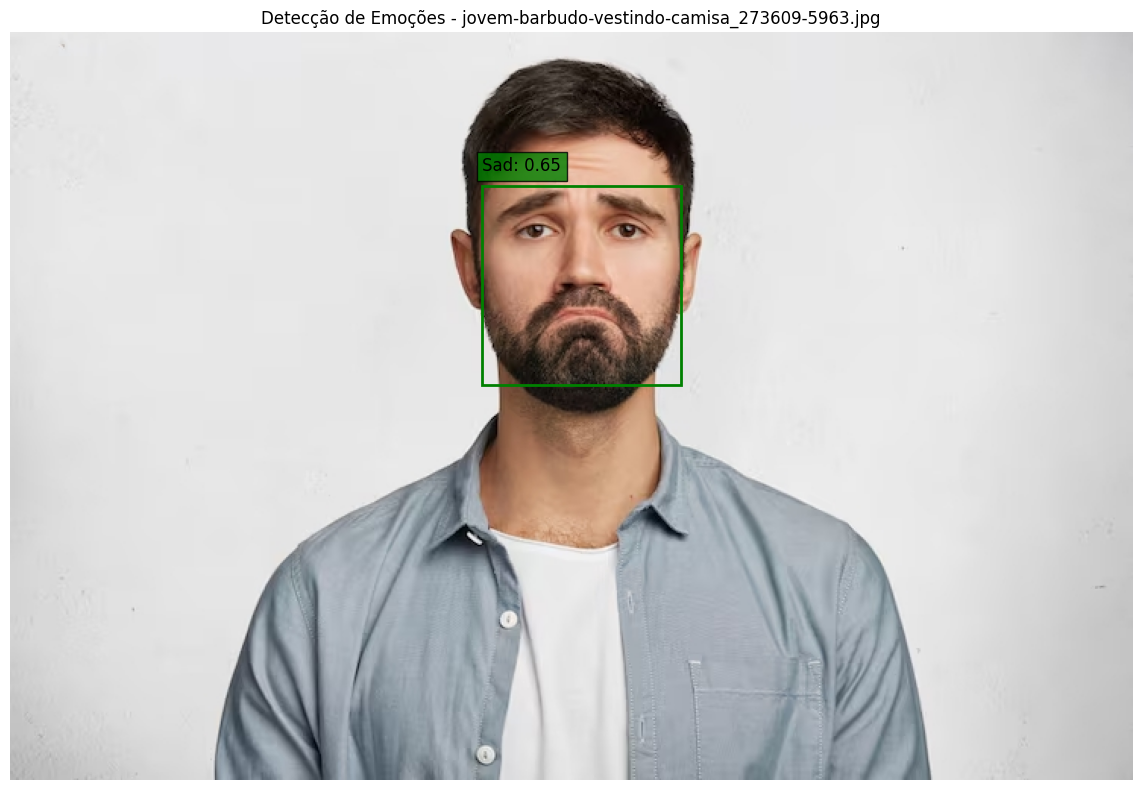

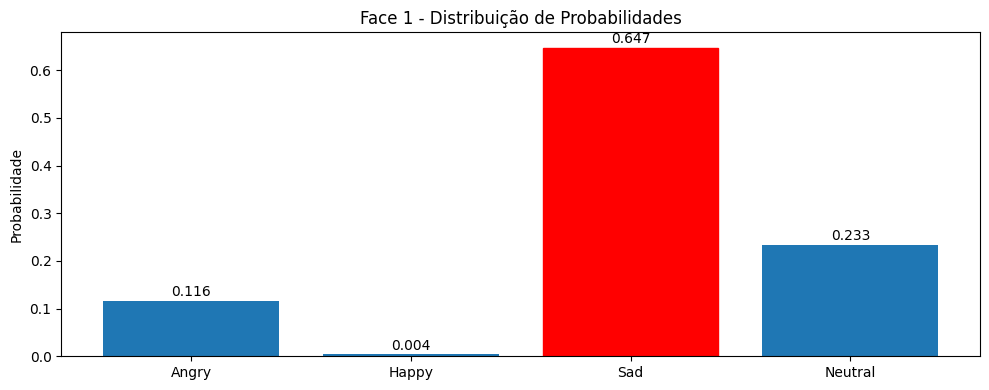

In [ ]:
main()

# Download do Modelo

In [26]:
def download_model_from_colab():
    """Baixa o modelo treinado do Colab"""

    from google.colab import files
    import os
    import torch

    print("📦 Preparando modelo para download...")

    # Verificar se o modelo existe
    if os.path.exists('best_emotion_model.pth'):
        print("✅ Modelo encontrado: best_emotion_model.pth")

        # Criar um dicionário com informações do modelo
        model_info = {
            'model_state_dict': torch.load('best_emotion_model.pth', map_location='cpu'),
            'emotion_labels': ['Angry', 'Happy', 'Sad', 'Neutral'],
            'model_architecture': 'EfficientNet-B0',
            'num_classes': 4,
            'input_size': (224, 224),
            'normalization': {
                'mean': [0.485, 0.456, 0.406],
                'std': [0.229, 0.224, 0.225]
            }
        }

        # Salvar informações completas
        torch.save(model_info, 'emotion_model_complete.pth')

        print("💾 Fazendo download dos arquivos...")

        # Download do modelo básico
        files.download('best_emotion_model.pth')

        # Download do modelo com informações completas
        files.download('emotion_model_complete.pth')

        print("✅ Download concluído!")
        print("📁 Arquivos baixados:")
        print("  • best_emotion_model.pth (apenas pesos)")
        print("  • emotion_model_complete.pth (modelo + metadados)")

    else:
        print("❌ Modelo não encontrado. Certifique-se de ter treinado o modelo primeiro.")

In [27]:
download_model_from_colab()

📦 Preparando modelo para download...
✅ Modelo encontrado: best_emotion_model.pth
💾 Fazendo download dos arquivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download concluído!
📁 Arquivos baixados:
  • best_emotion_model.pth (apenas pesos)
  • emotion_model_complete.pth (modelo + metadados)
